<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_01_Chocolate_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

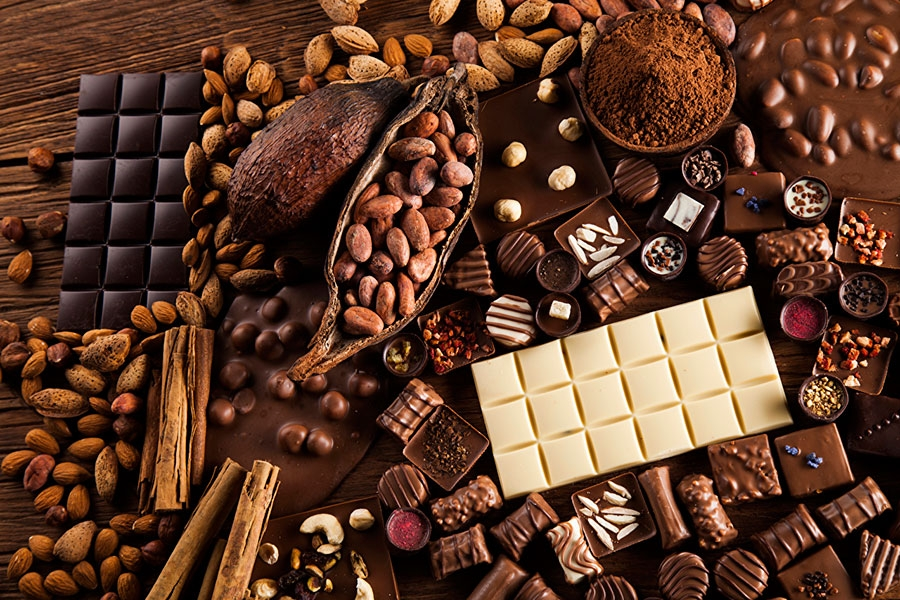

# Chocolate Sales Analysis – Final Report

## Dataset Overview
- 1094 sales records
- 6 columns analyzed

## Key Findings
### Product with highest sales
(Smooth Sliky Salty)

### Top country by revenue
(Australia)

### Most shipped product
(50% Dark Bites)

## Recommendations
- Focus on best-selling products
- Expand in top market
- Maintain stock of high-
##Profit Analysis
- Current Profit:$1,236,725
- Expected Increase
- if recommendations
 are implemented:$272,079.50
- Expected Profit Increase (%):22%

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("Chocolate Sales.csv")

In [ ]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [ ]:
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1551071879.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

In [ ]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


In [ ]:
print("Duplicates:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum())

Duplicates: 0
Missing values:
 Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [ ]:
sales_by_product = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
sales_by_product

,Amount
Product,
Smooth Sliky Salty,349692.0
50% Dark Bites,341712.0
White Choc,329147.0
Peanut Butter Cubes,324842.0
Eclairs,312445.0
99% Dark & Pure,299796.0
85% Dark Bars,299229.0
Organic Choco Syrup,294700.0
Spicy Special Slims,293454.0


/tmp/ipython-input-3520451825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette='viridis')


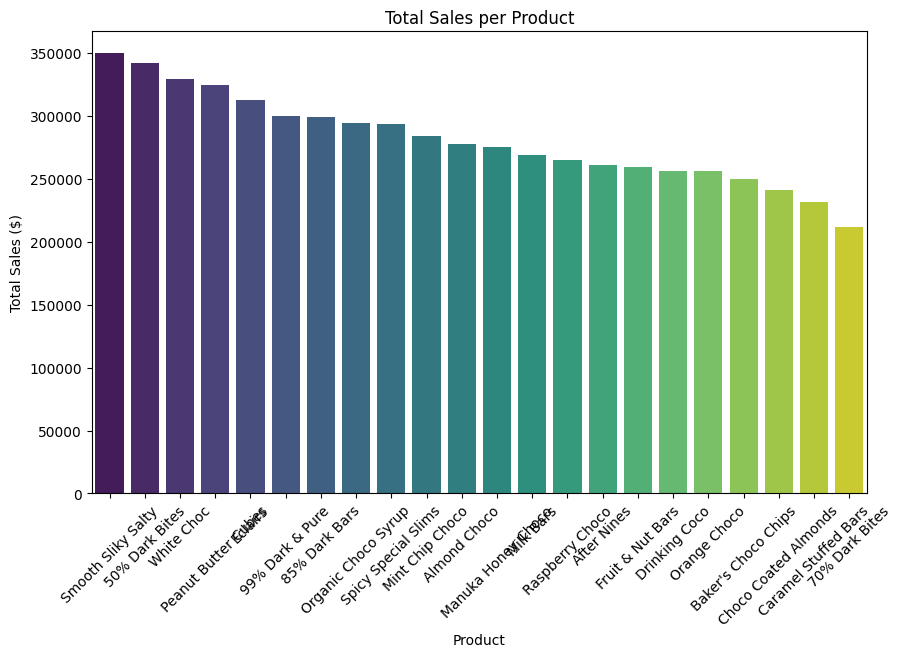

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette='viridis')
plt.xticks(rotation=45)
plt.title("Total Sales per Product")
plt.ylabel("Total Sales ($)")
plt.xlabel("Product")
plt.show()

In [ ]:
sales_by_country = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
sales_by_country

,Amount
Country,
Australia,1137367.0
UK,1051792.0
India,1045800.0
USA,1035349.0
Canada,962899.0
New Zealand,950418.0


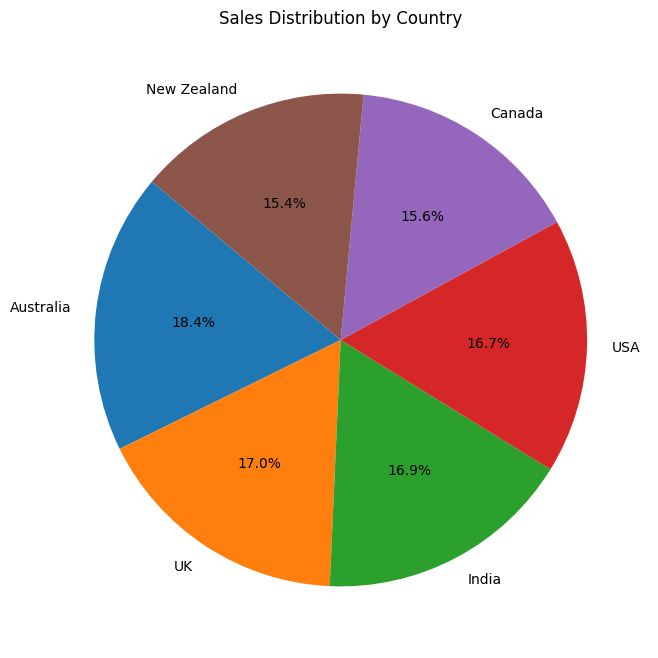

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(sales_by_country, labels=sales_by_country.index, autopct='%1.1f%%', startangle=140)
plt.title("Sales Distribution by Country")
plt.show()

In [ ]:
boxes_by_product = df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False)
boxes_by_product

,Boxes Shipped
Product,
50% Dark Bites,9792
Smooth Sliky Salty,8810
Eclairs,8757
Caramel Stuffed Bars,8717
Spicy Special Slims,8685
Drinking Coco,8660
Milk Bars,8330
Peanut Butter Cubes,8304
After Nines,8257


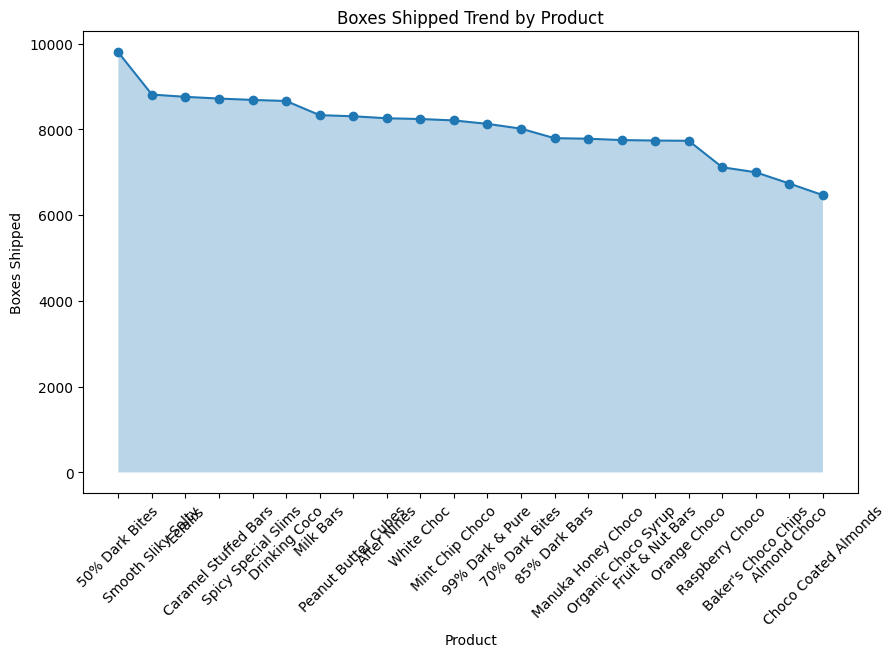

In [ ]:
plt.figure(figsize=(10,6))
plt.fill_between(
    boxes_by_product.index,
    boxes_by_product.values,
    alpha=0.3
)
plt.plot(boxes_by_product.index, boxes_by_product.values, marker='o')

plt.xticks(rotation=45)
plt.title("Boxes Shipped Trend by Product")
plt.xlabel("Product")
plt.ylabel("Boxes Shipped")
plt.show()

In [ ]:
# المبيعات الحالية للمنتجات والدولة المحددة
focus_df = df[
    (df['Country'] == "Australia") &
    ((df['Product'] == "50% Dark Bites") | (df['Product'] == "Smooth Sliky Salty"))]
# إجمالي المبيعات الحالية لهذه المنتجات
current_sales_focus = focus_df['Amount'].sum()
# نفترض زيادة 10% بعد تنفيذ التوصيات
expected_increase = current_sales_focus *0.10

In [ ]:
# إجمالي المبيعات لكل المنتجات
total_sales = df['Amount'].sum()
# نسبة الزيادة على المبيعات الإجمالية
profit_increase_percent = (expected_increase / total_sales) * 100
print(f"Expected Profit Increase for the client: {profit_increase_percent:.2f}%")

Expected Profit Increase for the client: 0.22%


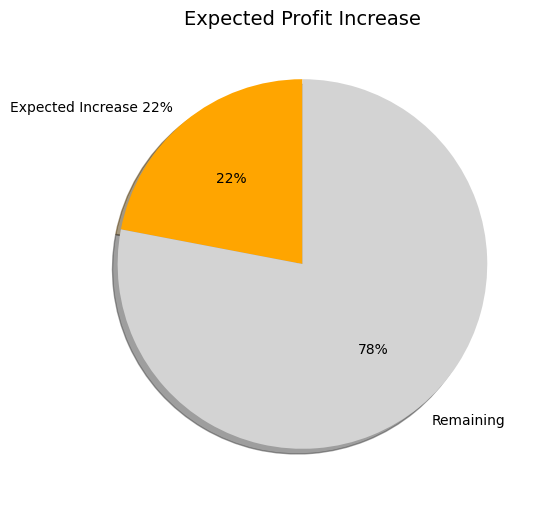

In [ ]:
plt.figure(figsize=(6,6))
plt.pie([increase_percent, 100-increase_percent],
        labels=[f'Expected Increase {increase_percent}%', 'Remaining'],
        colors=['orange', 'lightgray'],
        startangle=90,
        autopct='%1.0f%%',
        shadow=True)
plt.title("Expected Profit Increase", fontsize=14)
plt.show()

In [ ]:
profit_margin =0.20# 20% ربح من المبيعات الحاليه
current_profit = df['Amount'].sum() * profit_margin

print(f"Current Profit: ${current_profit:,.2f}")

Current Profit: $1,236,725.00


In [ ]:
# نسبة الزيادة المتوقعة
expected_increase_percent = 22  # 22%

# حساب الزيادة بالدولار
expected_increase = current_profit * (expected_increase_percent / 100)

print(f"Expected Increase: ${expected_increase:,.2f}")

Expected Increase: $272,079.50


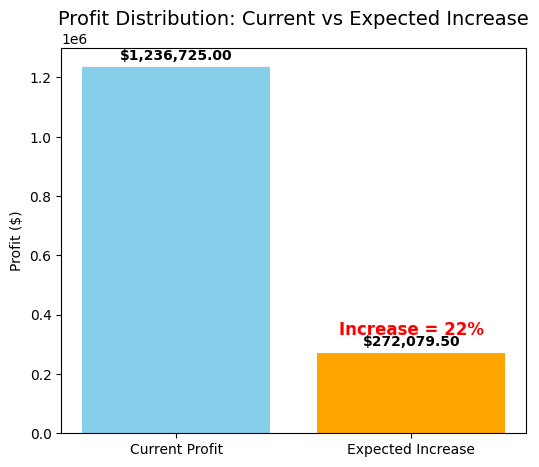

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(['Current Profit', 'Expected Increase'], [current_profit, expected_increase], color=colors)
plt.title("Profit Distribution: Current vs Expected Increase", fontsize=14)
plt.ylabel("Profit ($)")
for i, v in enumerate([current_profit, expected_increase]):
    plt.text(i, v + current_profit*0.02, f"${v:,.2f}", ha='center', fontweight='bold')
plt.text(1, expected_increase + current_profit*0.05, f"Increase = {increase_percent}%", ha='center', fontsize=12, fontweight='bold', color='red')
plt.show()